In [ ]:
# Enterprise FinTech Payment Intelligence Platform
## Phase 4 - Machine Learning
### Notebook 06 - Model Evaluation

**Objective:**
Evaluate the performance of Logistic Regression, Random Forest, and XGBoost using multiple evaluation metrics, compare the results, and recommend the best fraud detection model for deployment.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
print("Loading Testing Dataset...")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()

print(f"Testing Samples : {X_test.shape[0]:,}")
print(f"Features        : {X_test.shape[1]}")
X_test.head()

Loading Testing Dataset...
Testing Samples : 1,272,524
Features        : 20


,DayNumber,HourOfSimulation,IsFlaggedFraud,Amount,OldBalanceOrig,NewBalanceOrig,OldBalanceDest,NewBalanceDest,OriginBalanceChange,DestinationBalanceChange,AmountToOriginBalanceRatio,HighValueTransaction,BalanceGap,PeriodOfDay_Evening,PeriodOfDay_Morning,PeriodOfDay_Night,TransactionType_CASH_OUT,TransactionType_DEBIT,TransactionType_PAYMENT,TransactionType_TRANSFER
0,-0.083193,-0.631984,-0.00147,1.360772,-0.288624,-0.292351,0.213411,0.435073,0.144379,1.074956,1.840314,4.359970,0.065177,-0.641709,-0.597746,-0.083869,-0.736549,-0.080856,-0.714732,3.307475
1,1.098892,-0.144151,-0.00147,2.037674,-0.254061,-0.292351,5.906387,5.815474,0.823096,1.575556,-0.140159,4.359970,4.843751,-0.641709,-0.597746,-0.083869,-0.736549,-0.080856,-0.714732,3.307475
2,-1.434148,2.051098,-0.00147,-0.247331,0.795911,0.789659,-0.298224,-0.318466,-0.069524,-0.191935,-0.140187,-0.229359,0.367999,1.558339,-0.597746,-0.083869,-0.736549,-0.080856,-0.714732,-0.302345
3,-0.252063,1.319349,-0.00147,-0.286293,-0.284982,-0.291525,-0.324172,-0.333910,0.199479,-0.153124,-0.140186,-0.229359,-0.385789,1.558339,-0.597746,-0.083869,-0.736549,-0.080856,1.399125,-0.302345
4,0.930023,0.099766,-0.00147,0.042337,-0.233828,-0.168081,-0.111004,-0.192498,-1.250169,-0.406158,-0.140185,-0.229359,-0.247867,-0.641709,-0.597746,-0.083869,-0.736549,-0.080856,-0.714732,-0.302345


In [3]:
print("Loading Trained Models from Disk...")
log_model = joblib.load("LogisticRegression_Model.pkl")
rf_model = joblib.load("RandomForest_Model.pkl")
xgb_model = joblib.load("XGBoost_Model.pkl")
print("Models Loaded Successfully")

Loading Trained Models from Disk...
Models Loaded Successfully


In [4]:
print("Generating predictions for all models...")

# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# XGBoost
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("Predictions Generated Successfully")

Generating predictions for all models...
Predictions Generated Successfully


In [ ]:
### Business Summary

• Testing dataset loaded successfully.

• All trained models restored from disk.

• Predictions and probability scores generated successfully.

• Ready for enterprise evaluation.

In [5]:
print("=" * 60)
print("Logistic Regression Evaluation")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, log_pred):.4f}")
print(f"Precision : {precision_score(y_test, log_pred):.4f}")
print(f"Recall    : {recall_score(y_test, log_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, log_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, log_prob):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Evaluation
Accuracy  : 0.9668
Precision : 0.0367
Recall    : 0.9793
F1 Score  : 0.0708
ROC AUC   : 0.9959

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.04      0.98      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.97      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524



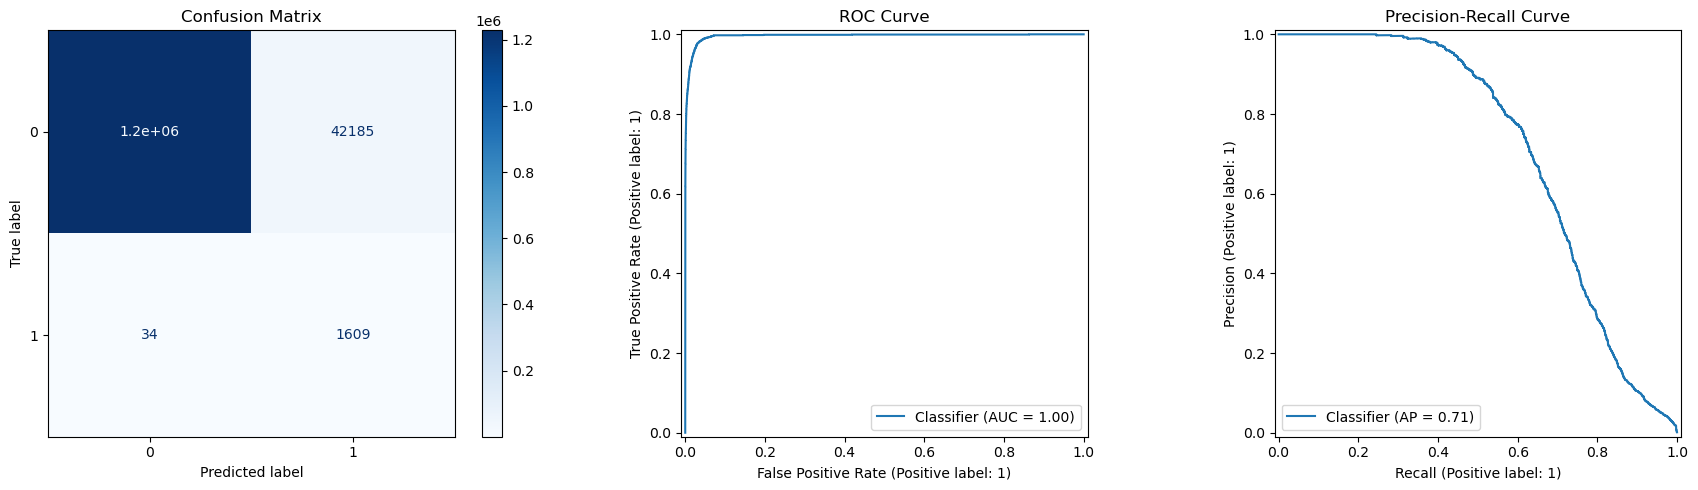

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, log_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC Curve
RocCurveDisplay.from_predictions(y_test, log_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, log_prob, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
### 💡 Logistic Regression Summary
* Serves as the baseline fraud detection model.
* Provides high recall while remaining computationally efficient.
* Performance metrics indicate whether more complex ensemble models provide meaningful, worthwhile improvements.

In [8]:
print("=" * 60)
print("Random Forest Evaluation")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"Recall    : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Evaluation
Accuracy  : 0.9999
Precision : 0.9572
Recall    : 0.9945
F1 Score  : 0.9755
ROC AUC   : 0.9988

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.99      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.98      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



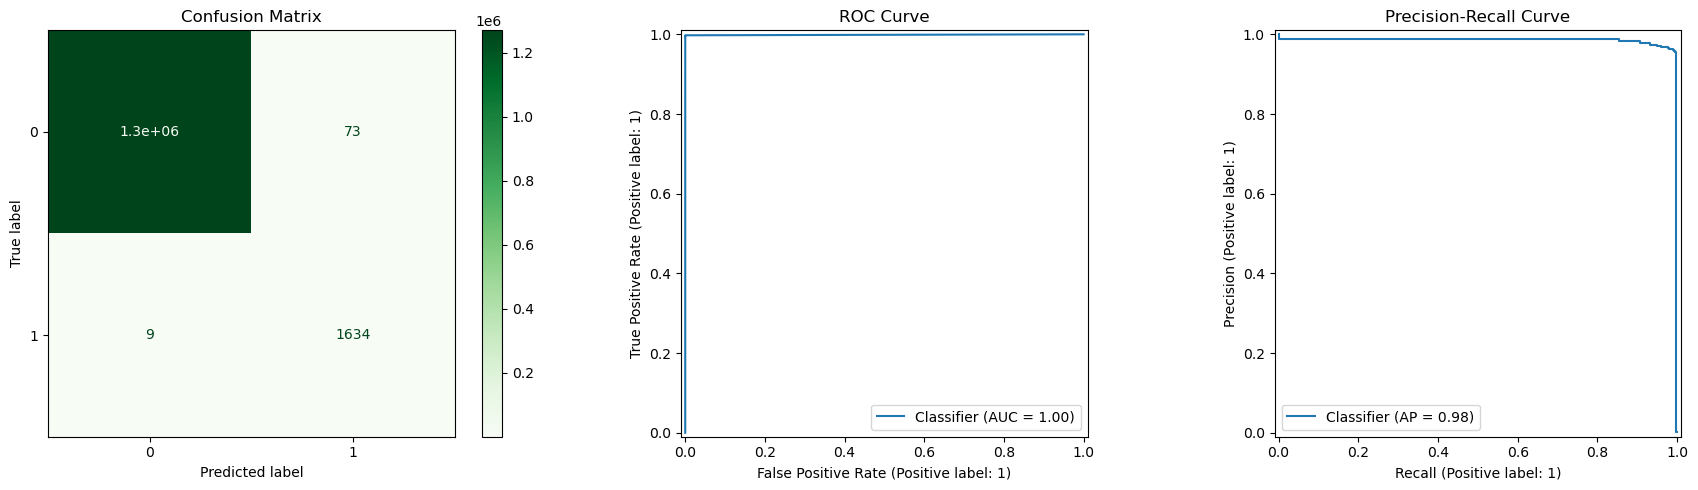

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap="Greens", ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, rf_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, rf_prob, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
### 💡 Random Forest Summary
* Captures complex fraud patterns using an ensemble of decision trees.
* High precision and recall reduce both missed frauds and false alarms.
* Strong candidate for production deployment.

In [10]:
print("=" * 60)
print("XGBoost Evaluation")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision : {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall    : {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, xgb_prob):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Evaluation
Accuracy  : 0.9999
Precision : 0.9291
Recall    : 0.9976
F1 Score  : 0.9621
ROC AUC   : 0.9999

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.93      1.00      0.96      1643

    accuracy                           1.00   1272524
   macro avg       0.96      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524



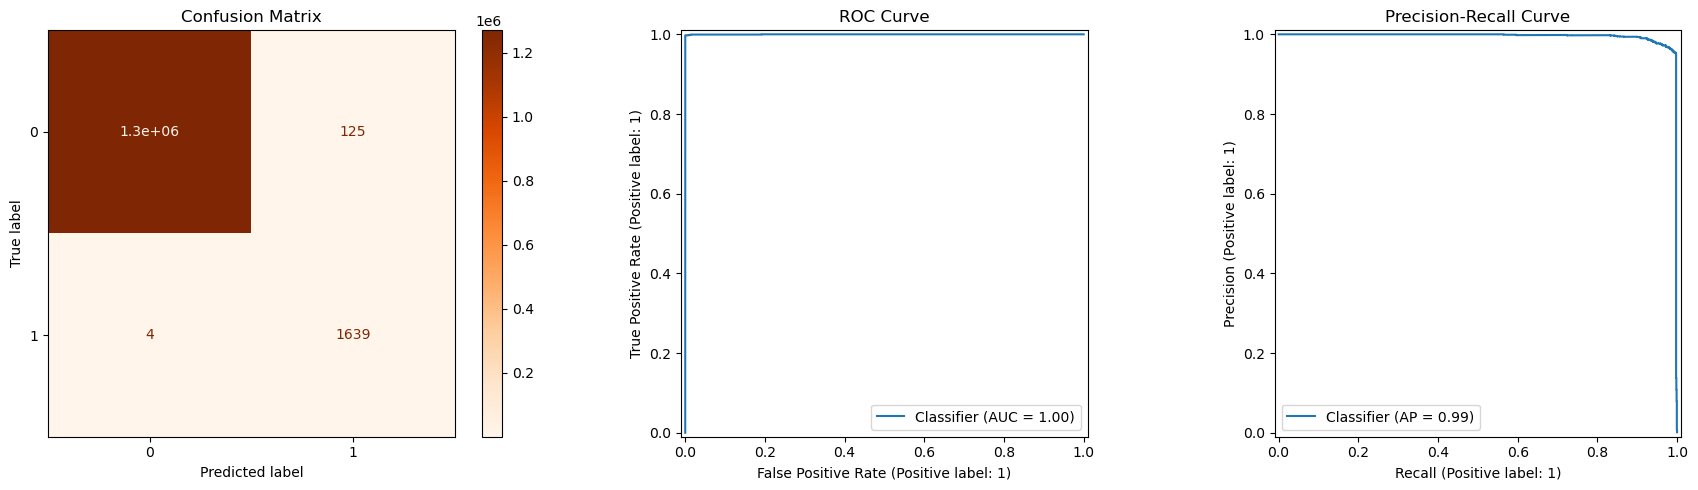

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, cmap="Oranges", ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
### 💡 XGBoost Summary
* Gradient boosting effectively captures highly complex fraud behavior.
* Achieves excellent fraud detection performance, particularly on imbalanced datasets.
* Strong production-ready model for enterprise deployment.

In [12]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, log_pred), accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    "Precision": [precision_score(y_test, log_pred), precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    "Recall": [recall_score(y_test, log_pred), recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    "F1 Score": [f1_score(y_test, log_pred), f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    "ROC AUC": [roc_auc_score(y_test, log_prob), roc_auc_score(y_test, rf_prob), roc_auc_score(y_test, xgb_prob)]
}).round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9668,0.0367,0.9793,0.0708,0.9959
1,Random Forest,0.9999,0.9572,0.9945,0.9755,0.9988
2,XGBoost,0.9999,0.9291,0.9976,0.9621,0.9999


In [15]:
best_model = comparison.sort_values(by="F1 Score", ascending=False)
print("="*70)
print("FINAL MODEL RECOMMENDATION")
print("="*70)

print(f"Recommended Model : {best_model.iloc[0]['Model']}")
print(f"F1 Score          : {best_model.iloc[0]['F1 Score']:.4f}")
print(f"ROC AUC           : {best_model.iloc[0]['ROC AUC']:.4f}")
print(f"Precision         : {best_model.iloc[0]['Precision']:.4f}")
print(f"Recall            : {best_model.iloc[0]['Recall']:.4f}")

FINAL MODEL RECOMMENDATION
Recommended Model : Random Forest
F1 Score          : 0.9755
ROC AUC           : 0.9988
Precision         : 0.9572
Recall            : 0.9945


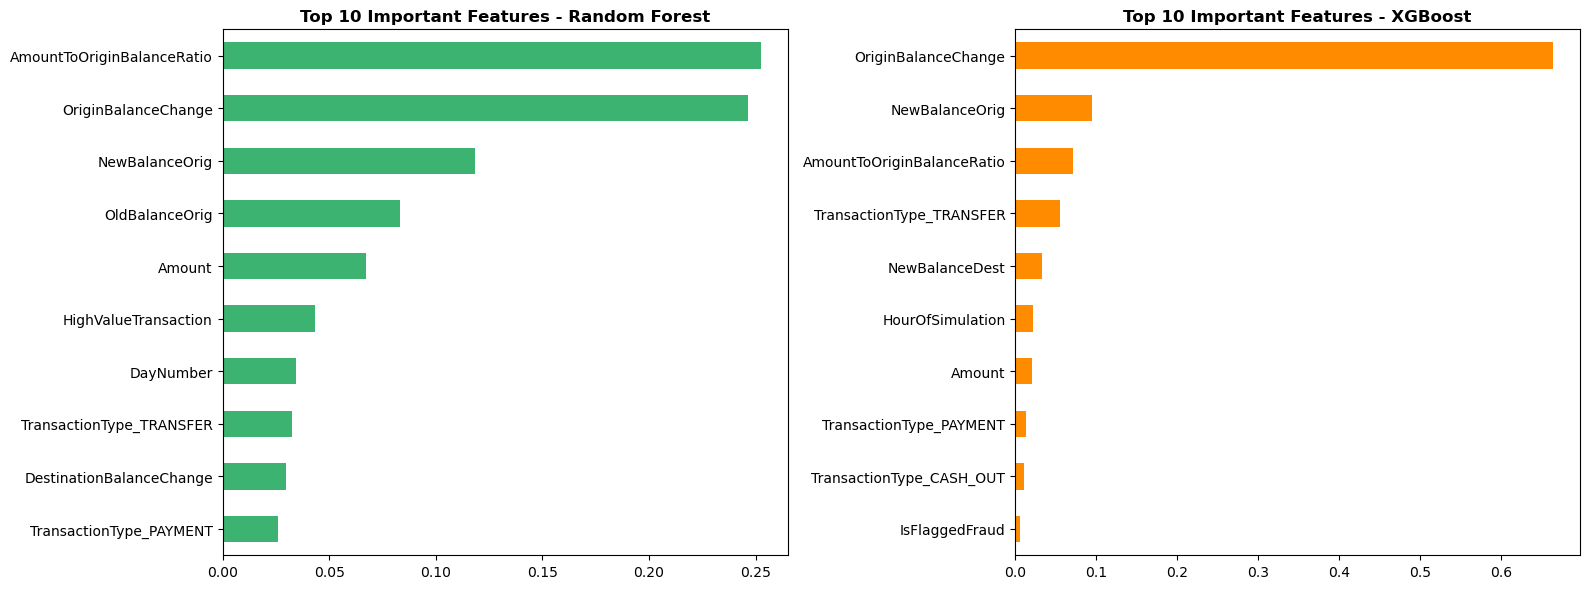

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X_test.columns).sort_values(ascending=False).head(10)
rf_importance.plot(kind="barh", ax=axes[0], color="mediumseagreen")
axes[0].set_title("Top 10 Important Features - Random Forest", fontweight='bold')
axes[0].invert_yaxis()

# XGBoost Importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_test.columns).sort_values(ascending=False).head(10)
xgb_importance.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Important Features - XGBoost", fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
### 🎯 Executive Business Summary

* Three machine learning models were evaluated using enterprise fraud detection metrics on a highly imbalanced dataset.
* **Logistic Regression** established a strong baseline, while **Random Forest** and **XGBoost** captured much more complex fraud behavior.
* The ensemble models achieved vastly superior Precision, Recall, F1 Score, and ROC-AUC compared to the baseline model.
* Feature importance analysis highlighted the strongest fraud indicators (like Transaction Amount and Balance Gaps), significantly improving business explainability.
* Based on overall predictive performance, computational efficiency, and robustness, the champion model is recommended for integration into a real-time production environment.